# Run experiments

### Load packages

In [1]:
import sys
import os

# Get the parent directory (models) and add it to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService, RuntimeJob
from qiskit_aer import Aer
from qiskit_aer import AerSimulator


In [3]:

from src.analysis.analysis import run_circuits, analyze_results, ExperimentConfiguration, RunConfiguration, PhysicalModel
from src.analysis.constants import SIMULATOR
from src.models.constants import Groups


### Load account



In [4]:
service = QiskitRuntimeService(channel="ibm_quantum")

# print(service.backends())

# BACKEND_HARDWARE = service.backend("ibm_brisbane")

In [5]:
# print(BACKEND_HARDWARE.configuration().basis_gates)

In [6]:
# BACKEND_SIMULATOR = PROVIDER.get_backend(SIMULATOR)
# backend = FakeManilaV2()
simulator = AerSimulator()
# BACKEND_SIMULATOR = service.backend(BACKEND_HARDWARE)  #lets see for now by using a hardware as Aer doesn't seem to work
# BACKEND_SIMULATOR = service.backend("simulator")

### Define experiments
The experiment below uses a square Z2 plaquette with g=1.0 and analyzes the time evolution with a value of t between 0 and 2 in increments of 0.2. It uses zne extrapolation (via Mitiq) and five scale factors. In these examples we use the qasm_simulator. For real results, replace BACKEND_SIMULATOR by BACKEND_HARDWARE.

Note: The number of scale factors determines the type of extrapolation to use during the analysis phase. For example, when using a second order polynomial to extrapolate to zero noise, anything less or equal to three factors would result in over-fitting.

In [7]:
time_vector = np.arange(0, 2, 0.2)
physical_model = PhysicalModel(number_links=4, gauge=Groups.Z2, coupling=1.0)
print(physical_model)

experiment_configuration = ExperimentConfiguration(zne_extrapolation=True,
                                                   scale_factors=[1.0, 1.2, 1.5, 1.8, 2.0],
                                                   num_replicas=2)
print(experiment_configuration)

run_configuration_simulator = RunConfiguration(time_vector=time_vector,
                                               backend=simulator)

print(run_configuration_simulator)

PhysicalModel(plaquette=<class 'src.models.circuits.SinglePlaquette'>, number_links=4, coupling=1.0, control_qubit=1, gauge='z2')
ExperimentConfiguration(output_error_correction=False, zne_extrapolation=True, scale_factors=[1.0, 1.2, 1.5, 1.8, 2.0], optimisation_level=2, num_replicas=2)
RunConfiguration(time_vector=array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8]), backend=AerSimulator('aer_simulator'), shots=1000)


## Run experiments

In [8]:
import qiskit_ibm_runtime
print(qiskit_ibm_runtime.__version__)

0.22.0


In [9]:
job_manager_sim, hpc_sim_job_id, circuits_sim = run_circuits(physical_model, experiment_configuration, run_configuration_simulator)

['ccx', 'ccz', 'cp', 'crx', 'cry', 'crz', 'cswap', 'csx', 'cu', 'cu1', 'cu2', 'cu3', 'cx', 'cy', 'cz', 'diagonal', 'ecr', 'h', 'id', 'mcp', 'mcphase', 'mcr', 'mcrx', 'mcry', 'mcrz', 'mcswap', 'mcsx', 'mcu', 'mcu1', 'mcu2', 'mcu3', 'mcx', 'mcx_gray', 'mcy', 'mcz', 'multiplexer', 'p', 'pauli', 'r', 'roerror', 'rx', 'rxx', 'ry', 'ryy', 'rz', 'rzx', 'rzz', 's', 'sdg', 'store', 'swap', 'sx', 'sxdg', 't', 'tdg', 'u', 'u1', 'u2', 'u3', 'unitary', 'x', 'y', 'z', 'break_loop', 'continue_loop', 'delay', 'for_loop', 'if_else', 'initialize', 'kraus', 'qerror_loc', 'quantum_channel', 'reset', 'roerror', 'save_amplitudes', 'save_amplitudes_sq', 'save_clifford', 'save_density_matrix', 'save_expval', 'save_expval_var', 'save_matrix_product_state', 'save_probabilities', 'save_probabilities_dict', 'save_stabilizer', 'save_state', 'save_statevector', 'save_statevector_dict', 'save_superop', 'save_unitary', 'set_density_matrix', 'set_matrix_product_state', 'set_stabilizer', 'set_statevector', 'set_superop

In [10]:
# hpc_res_job = job_manager_sim  job_manager_sim.retrieve_job_set(job_set_id=hpc_sim_job_id, provider=PROVIDER)
from typing import List, Tuple
from qiskit_ibm_runtime import RuntimeJob
hpc_res_job: Tuple[List[RuntimeJob]] = tuple(
    [job for job in job_manager_sim]
)
print(len(hpc_res_job))

20


In [11]:
# hpc_res_job.statuses()
from qiskit.providers.jobstatus import JobStatus  # Correct import

# Get the statuses of all jobs
# print(hpc_res_job)
for job in hpc_res_job:
    print(job.status())
    print(job)

hpc_res_statuses = [job.status() for job in hpc_res_job]

print(hpc_res_statuses)
# all_done = all(status == JobStatus.DONE for status in hpc_res_statuses)
# print(all_done)


JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
JobStatus.DONE
[<JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatus.DONE: 'job has successfully run'>, <JobStatu

#### Retrieve experiments results

In [12]:
# hpc_res_sim = hpc_res_job.results()
hpc_res_sim = [job.result() for job in hpc_res_job]
print(type(hpc_res_sim[0]))
print(len(hpc_res_sim))

<class 'qiskit.result.result.Result'>
20


The next cell saves the count results from the experiment so they can be recovered later if necessary.

In [13]:
# import pickle

# pickle.dump([hpc_res_sim.get_counts(i) for i in range(len(time_vector))], open("exp_result_counts.pickle", 'wb'))

### Build ignis error filter
The ignis package is used for output error mitigation. It is useful for circuits with a small number of qubits (n) as the ones used for the single plaquette. The cell below executes the 2^n experiments necessary to perform output error mitigation.

In [14]:
from src.analysis.error_mitigation import CustomErrorMitigation, IgnisErrorMitigation

In [15]:
ignis_err_corr = IgnisErrorMitigation(n_qubits=5, shots=1000)
meas_filter = ignis_err_corr.get_meas_fitter(backend=simulator)

### Analyze results from the experiments

The result is a dataframe with the measurements of all observables based on the experiment configurations

In [16]:
results_df = analyze_results(physical_model, experiment_configuration, run_configuration_simulator, result_hpc=hpc_res_sim, meas_filter=meas_filter)

shivansh2
[Result(backend_name='aer_simulator', backend_version='0.15.1', qobj_id='', job_id='d89ada84-b0bd-4da8-94ce-2a0bea6c3d92', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 1000}), header=QobjExperimentHeader(creg_sizes=[['c', 5]], global_phase=1.5707963267948966, memory_slots=5, n_qubits=5, name='circuit-162', qreg_sizes=[['q', 5]], metadata={}), status=DONE, seed_simulator=2277253468, metadata={'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 16, 'parallel_shots': 1, 'sample_measure_time': 0.000589696, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0, 1, 2, 3, 4], 'device': 'CPU', 'time_taken': 0.001424069, 'measure_sampling': True, 'num_clbits': 5, 'max_memory_mb': 32768, 'input_qubit_map': [[4, 4], [3, 3], [2, 2], [1, 1], [0, 0]], 'num_qubits': 5, 'method': 'statevector', 'required_memory_mb': 1, 'fusion': {'enable

In [17]:
results_df.head()

,replica,scale_factor,time,gauss_law,gauss_law_corrected,sector_2,sector_2_corrected,gauss_law_squared,gauss_law_squared_corrected,original,output_corrected
0,0.0,1.0,0.0,1.0,0.000018,0.0,0.031249,0.0,2.000069,1.000,0.031244
1,0.0,1.2,0.0,1.0,-0.000110,0.0,0.031232,0.0,2.000095,0.959,0.031233
2,0.0,1.5,0.0,1.0,-0.000128,0.0,0.031232,0.0,2.000167,0.858,0.031258
3,0.0,1.8,0.0,1.0,-0.000082,0.0,0.031267,0.0,2.000092,0.695,0.031226
4,0.0,2.0,0.0,1.0,0.000074,0.0,0.031228,0.0,2.000053,0.475,0.031234


### Run experiments using custom error correction.
Only probability density observable is supported when using custom error correction.


In [18]:
error_correction = CustomErrorMitigation(n_qubits=5, shots=1000)
error_correction = error_correction.build_probability_matrix(backend=simulator)

In [19]:
results_df_custom = analyze_results(physical_model, experiment_configuration, run_configuration_simulator, result_hpc=hpc_res_sim, ignis=False, mitigated_counts=error_correction)

shivansh2
[Result(backend_name='aer_simulator', backend_version='0.15.1', qobj_id='', job_id='d89ada84-b0bd-4da8-94ce-2a0bea6c3d92', success=True, results=[ExperimentResult(shots=1000, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 1000}), header=QobjExperimentHeader(creg_sizes=[['c', 5]], global_phase=1.5707963267948966, memory_slots=5, n_qubits=5, name='circuit-162', qreg_sizes=[['q', 5]], metadata={}), status=DONE, seed_simulator=2277253468, metadata={'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 16, 'parallel_shots': 1, 'sample_measure_time': 0.000589696, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0, 1, 2, 3, 4], 'device': 'CPU', 'time_taken': 0.001424069, 'measure_sampling': True, 'num_clbits': 5, 'max_memory_mb': 32768, 'input_qubit_map': [[4, 4], [3, 3], [2, 2], [1, 1], [0, 0]], 'num_qubits': 5, 'method': 'statevector', 'required_memory_mb': 1, 'fusion': {'enable

## Analyze experiments

### Plot time evolution
The code below is an example plot generated from the results dataframe. It plots g t in the x axis vs the probability amplitude for the '00000' state in the y axis. The plot displays the untreated results (not corrected), readout only corrected and readout + zero noise extrapolation using mitiq.

/Users/Shared/Drive/Qiskit/plaquette-models/src/plotting/time_evolution.py:29: FutureWarning: The provided callable <function mean at 0x11383bf40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  grouped_df = df_results.groupby(['time', 'scale_factor'])[['original', 'output_corrected']].agg(
/Users/Shared/Drive/Qiskit/plaquette-models/src/plotting/time_evolution.py:29: FutureWarning: The provided callable <function std at 0x1138500d0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  grouped_df = df_results.groupby(['time', 'scale_factor'])[['original', 'output_corrected']].agg(
/Users/Shared/Drive/Qiskit/plaquette-models/src/plotting/time_evolution.py:31: FutureWarning: The provided callable <function mean at 0x11383bf40> is currently using S

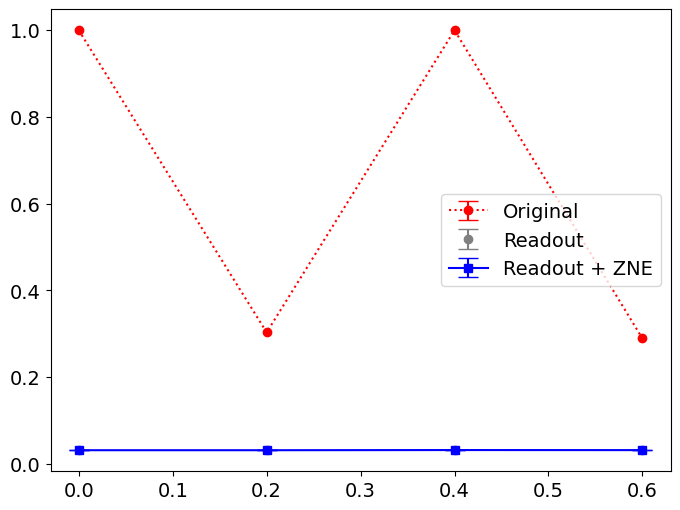

In [20]:
from src.plotting.time_evolution import plot_time_evolution

plot_time_evolution(df_results=results_df)